#Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
print("Libraries loaded!")


Libraries loaded!


#Load Raw Data


In [2]:
df = pd.read_csv('TSLA_messy.csv') 
print("Raw data loaded!")
print("Rows:", len(df), "| Columns:", len(df.columns))
df.head()

Raw data loaded!
Rows: 2967 | Columns: 7


,Date,Open,High,Low,Close,Adj Close,Volume
0,2011-09-16,4.956,5.168000,4.898000,5.160000,5.160000,7085500.0
1,2012-01-23,5.362,5.442000,5.320000,5.354000,5.354000,2973000.0
2,2021-01-13,852.76001,860.469971,832.000000,854.409973,854.409973,33312500.0
3,2011-06-28,5.558,5.650000,5.534000,5.622000,5.622000,4446000.0
4,2015-09-11,49.528,50.048000,48.945999,50.048000,50.048000,11754000.0


#3.Frist look

In [3]:
print("Shape (rows,columns):", df.shape)
print("\nColumns name:", list(df.columns))
print("\nData types:")
print(df.dtypes)

Shape (rows,columns): (2967, 7)

Columns name: ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

Data types:
Date          object
Open          object
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume        object
dtype: object


#4.Check Missing Values

In [4]:
missing = df.isnull().sum()
print("Missing values in each column:")
print(missing)
print("\nTotal missing:", missing.sum())

Missing values in each column:
Date         0
Open         3
High         3
Low          3
Close        3
Adj Close    3
Volume       4
dtype: int64

Total missing: 19


#5. Check Duplicate Rows 

In [5]:
dup_all = df.duplicated().sum()
dup_dates = df.duplicated(subset=['Date']).sum()
print(df.info())
print("Duplicate rows:", dup_all)
print("Duplicate dates:", dup_dates)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2967 entries, 0 to 2966
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2967 non-null   object 
 1   Open       2964 non-null   object 
 2   High       2964 non-null   float64
 3   Low        2964 non-null   float64
 4   Close      2964 non-null   float64
 5   Adj Close  2964 non-null   float64
 6   Volume     2963 non-null   object 
dtypes: float64(4), object(3)
memory usage: 162.4+ KB
None
Duplicate rows: 8
Duplicate dates: 11


#6.Fix data Types

In [6]:

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'], format='mixed', errors='coerce')

# Check for invalid dates
print("Invalid dates:", df['Date'].isna().sum())

# Check date range
print("Date range:", df['Date'].min().date(), "to", df['Date'].max().date())

# Check data types
print(df.dtypes)


Invalid dates: 2
Date range: 2010-06-29 to 2022-03-24
Date         datetime64[ns]
Open                 object
High                float64
Low                 float64
Close               float64
Adj Close           float64
Volume               object
dtype: object


7.Remove Duplicates and Sort

In [7]:
before = len(df)

df = df.drop_duplicates(subset=['Date'])
df = df.sort_values('Date').reset_index(drop=True)

after = len(df)
print(f"Rown before: {before}")
print(f"Rown after:  {after}")
print(f"Removed:     {before - after}")


Rown before: 2967
Rown after:  2956
Removed:     11


#8. Logic Checks

In [10]:
before = len(df)

for col in ['Open', 'Close', 'High', 'Low', 'Volume']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df[df['Close'] > 0]
df = df[df['Open'] > 0]
df = df[df['High'] >= df['Low']]
df = df[df['Volume'] > 0]

after = len(df)
print(f"Bad rows removed: {before - after}")
print(f"Clean rows left:  {after}")


Bad rows removed: 0
Clean rows left:  2929


#9. Create Helpful New Columns

In [11]:
df['Year'] = df['Date'].dt.year
df['Price_Range'] = df['High'] - df['Low']

print("New columns added: Year, Price_Range")
df[['Date', 'Open', 'Close', 'Year', 'Price_Range']].head()

New columns added: Year, Price_Range


,Date,Open,Close,Year,Price_Range
0,2010-06-29,3.800,4.778,2010.0,1.492
1,2010-06-30,5.158,4.766,2010.0,1.424
2,2010-07-01,5.000,4.392,2010.0,1.130
3,2010-07-02,4.600,3.840,2010.0,0.878
4,2010-07-06,4.000,3.222,2010.0,0.834


#10.Final Cleaning Check

In [12]:
print("===CLEAN DATA REPORT===")
print("Rows:", len(df))
print("Missing values:", df.isnull().sum().sum())
print("Duplicates:", df.duplicated().sum())
print("Negative Close prices:", (df['Close'] < 0).sum())
print("High < Low rows:", (df['High'] <  df['Low']).sum())
print("\nBasic status:")
df[['Open', 'Close', 'High', 'Low', 'Volume']].describe()

===CLEAN DATA REPORT===
Rows: 2929
Missing values: 2
Duplicates: 0
Negative Close prices: 0
High < Low rows: 0

Basic status:


,Open,Close,High,Low,Volume
count,2929.000000,2929.000000,2929.000000,2929.000000,2.929000e+03
mean,141.438749,141.360436,144.552019,138.011889,3.132930e+07
std,312.852095,307.824956,318.880265,302.743593,2.802965e+07
min,3.228000,3.160000,3.326000,-48.127998,5.925000e+05
25%,19.785999,19.910000,20.504000,19.150000,1.311450e+07
50%,46.700001,46.590000,47.495998,45.824001,2.488110e+07
75%,67.991997,67.970001,69.164001,66.842003,3.973700e+07
max,10417.099610,9956.500240,10546.700440,9950.000000,3.046940e+08


#11.Quick Visual Check

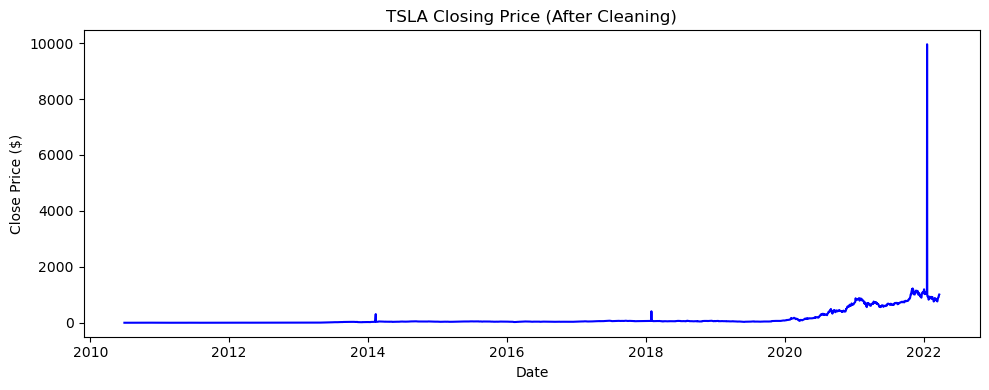

In [14]:
plt.figure(figsize=(10, 4))
plt.plot(df['Date'], df['Close'], color='blue')
plt.title('TSLA Closing Price (After Cleaning)')
plt.xlabel('Date')
plt.ylabel('Close Price ($)')
plt.tight_layout()
plt.show()


#12, Save Cleaning Data

In [15]:
df.to_csv('TSLA_messy_clean.csv', index=False)
print("Saved as TSLA_messy_clean.csv")

Saved as TSLA_messy_clean.csv
